# Step 50b — Model C: eta0 stability comparison (extension of #50)

Focused follow-up to notebook 50's Part 2/3: compares `eta0=1` vs `eta0=0.01` (same `epsilon`,
`penalty`, `learning_rate="pa1"`, `random_state`) against raw BTC buy-and-hold, on the real
BTC replication. Same data, same math — this notebook only builds the 3-way stacked
equity-curve and drawdown views, since that comparison surfaced real insight (`eta0=0.01`
tracks BTC's own trend almost exactly; `eta0=1` behaves more independently, with a shallower
max drawdown despite far noisier w/b).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')

btcusdt = pd.read_csv('BTCUSDT_1d_author_original.csv')
btcusdt['t'] = pd.to_datetime(btcusdt['t'])
btcusdt.set_index('t', inplace=True)
btcusdt['close_log_return'] = np.log(btcusdt['c'] / btcusdt['c'].shift())
btcusdt['close_log_return_lag_1'] = btcusdt['close_log_return'].shift()

# Same date filter as notebook 50 — Train start date 2020-09-29, where the author's
# close_log_return_ma_lag_1 40-day warmup would have finished.
df_clean = btcusdt.dropna()
df_clean = df_clean[df_clean.index >= '2020-09-29']

X_stream = df_clean[['close_log_return_lag_1']].to_numpy()
y_stream = df_clean['close_log_return'].to_numpy()
print('n rows in stream:', len(X_stream))

n rows in stream: 2056


In [2]:
def run_replication(eta0):
    model = SGDRegressor(loss="epsilon_insensitive", epsilon=0.0002, penalty=None,
                          learning_rate="pa1", eta0=eta0, random_state=69)
    scaler = StandardScaler()
    rows = []
    for t in range(len(X_stream)):
        X_t = X_stream[t].reshape(1, -1)
        y_t = np.array([y_stream[t]])
        scaler.partial_fit(X_t)
        X_t_scaled = scaler.transform(X_t)
        pred_y = 0.0 if t == 0 else model.predict(X_t_scaled)[0]
        model.partial_fit(X_t_scaled, y_t)
        signal = np.sign(pred_y)
        rows.append({'tick': t, 'trade_log_return': signal * y_t[0]})
    df = pd.DataFrame(rows).set_index('tick')
    # trade_log_return is structurally 0 on warmup ticks (signal=0), so a plain cumsum
    # naturally carries the running total forward with no gaps.
    df['cum'] = df['trade_log_return'].cumsum()
    return df

df_eta1 = run_replication(eta0=1)
df_eta001 = run_replication(eta0=0.01)

# Raw BTC "buy and hold" — cumulative log return of BTC itself, same tick index/period,
# for comparison against both Model C configs.
raw_btc_cum = pd.Series(y_stream, index=range(len(y_stream))).cumsum()
raw_btc_cum.index.name = 'tick'

def drawdown(cum_series):
    return cum_series - cum_series.cummax()

curves = [
    ('eta0=1 (Model C)', df_eta1['cum'], '#e67e22'),
    ('eta0=0.01 (Model C)', df_eta001['cum'], '#2ecc71'),
    ('Raw BTC buy-and-hold', raw_btc_cum, '#4a90d9'),
]

for label, cum, _ in curves:
    print(f'{label}: final cum return = {cum.iloc[-1]:.4f}   max drawdown = {drawdown(cum).min():.4f}')

eta0=1 (Model C): final cum return = 0.6119   max drawdown = -0.8796
eta0=0.01 (Model C): final cum return = 0.4893   max drawdown = -2.1222
Raw BTC buy-and-hold: final cum return = 1.9875   max drawdown = -1.4554


### Equity curves — eta0=1, eta0=0.01, raw BTC — stacked

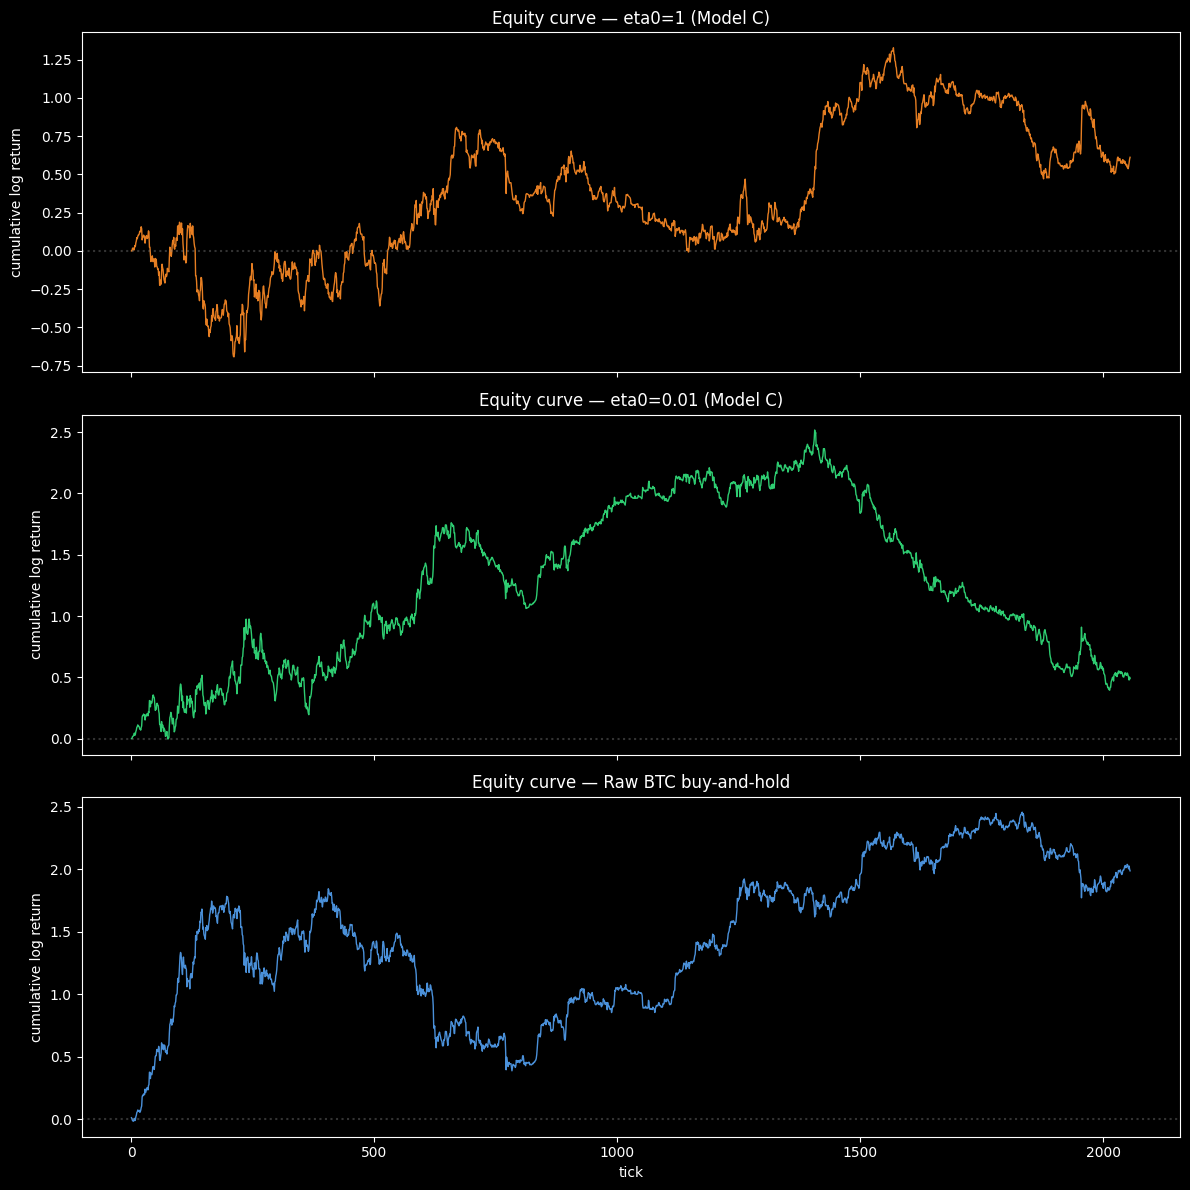

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, (label, cum, color) in zip(axes, curves):
    ax.plot(cum.index, cum, color=color, linewidth=1.0)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(f'Equity curve — {label}')
    ax.set_ylabel('cumulative log return')

axes[-1].set_xlabel('tick')
plt.tight_layout()
plt.show()

### Drawdown curves — eta0=1, eta0=0.01, raw BTC — stacked

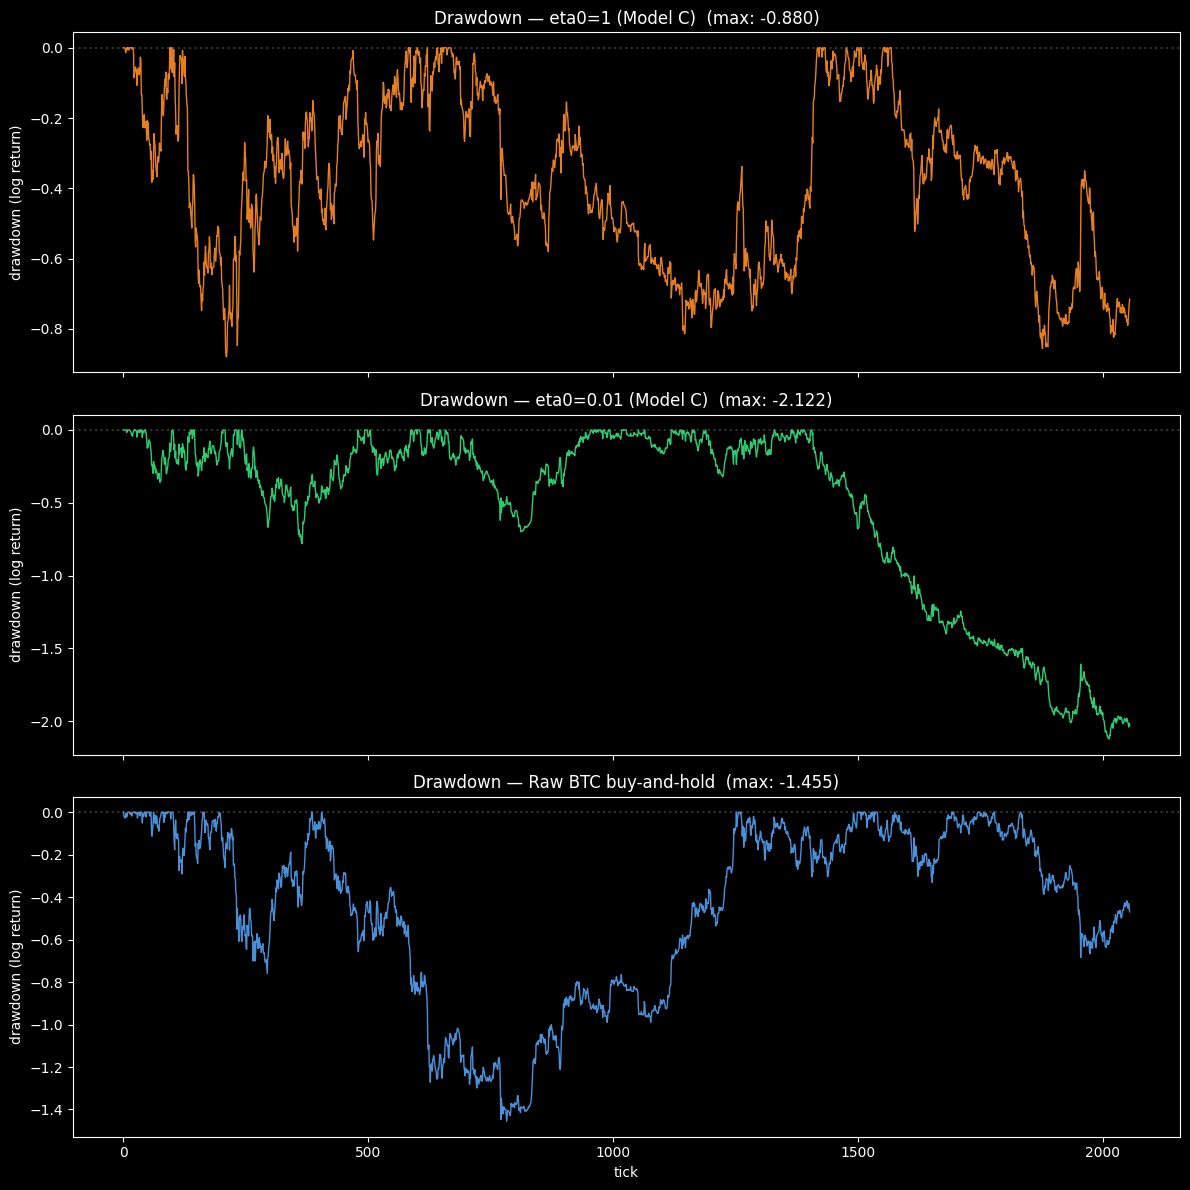

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, (label, cum, color) in zip(axes, curves):
    dd = drawdown(cum)
    ax.plot(dd.index, dd, color=color, linewidth=1.0)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(f'Drawdown — {label}  (max: {dd.min():.3f})')
    ax.set_ylabel('drawdown (log return)')

axes[-1].set_xlabel('tick')
plt.tight_layout()
plt.show()